# Notebook 16 — Environment-coupled fold gate (plan Phase 0.5)

**The real go/no-go for the model.** Notebook 15 validated the social subsystem with the
environment *off* (`private_kappa=0`): the softmax-precision channel folds at $K_c=2$. But the full
model adds the object-level evidence — each agent reads experiments through its paradigm's likelihood
$A_\theta(o|s,a)$, pulling beliefs toward the true paradigm. The mediating-field note names the real
test: *"a large environment pull flattens the effective $F$; the competition is $F'$ vs 1 once the
environment is folded in"* and *"test the fold, not the trajectory."*

This notebook folds the environment in, plus the **belief-utility tilt** (the David reframing's
symmetry-breaking field that turns polarization into capture). All at the cheap mean-field / finite-N
level — no pymdp scaffold yet.

### The tilted mean-field map
Convention: **paradigm B is true**, so $+\ell$ favours the truth. The log-odds fixed point gains a
constant net field:
$$\ell^\star = K\,(2\sigma(\ell^\star)-1) + B_{\rm field},\qquad B_{\rm field}=d + h_U,\quad K=\kappa_{\rm soc}/\lambda.$$
- $d\ge 0$ — **environment pull** toward true B, set by **theory discriminability** (per-row KL
  between paradigms' predicted columns; low $d$ = underdetermined / theory-laden data).
- $h_U$ — **belief-utility tilt**; $h_U<0$ favours the *wrong* paradigm A (motivated reasoning).

The tilt unfolds the pitchfork into a cusp: as $|B_{\rm field}|$ grows the minority basin dies in a
saddle-node, so a sharply disambiguating environment (large $d$) **flattens the fold** to monostable.

### Verdict criteria
- Fold **survives** at plausible $d$ → green light for the scaffold (with the stated $d$ constraint).
- Belief-utility produces genuine **capture** (incl. capture of the *wrong* paradigm against weak
  evidence) → the asymmetric mechanism the symmetric NB15 pitchfork lacked.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / "src").exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.pomdp.social_fold import (
    sigmoid, reliability_to_precision,
    fixedpoint_residual_env, find_fixed_points_env, regime_grid,
    EnvConfig, simulate_env, capture_basin_test,
    MONOSTABLE_TRUTH, MONOSTABLE_WRONG, BISTABLE,
)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("imports OK")

imports OK


## 1. Does the fold survive the environment? Self-consistency curve at increasing $d$

Plot the map $g(\ell)=K(2\sigma(\ell)-1)+d$ against the identity. Intersections are fixed points; the
wrong-paradigm (A, $m<0.5$) basin is destroyed in a saddle-node as $d$ grows.

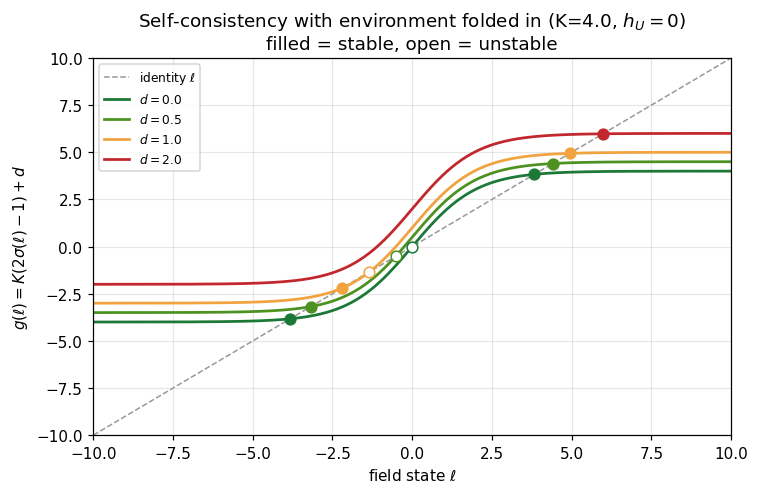

fixed points (m*, stable) vs d:
  d= 0.0: 0.021(s), 0.500(u), 0.979(s)
  d= 0.5: 0.040(s), 0.372(u), 0.988(s)
  d= 1.0: 0.099(s), 0.207(u), 0.993(s)
  d= 1.5: 0.996(s)
  d= 2.0: 0.997(s)


In [2]:
K = 4.0
ell = np.linspace(-10, 10, 400)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(ell, ell, color="0.6", ls="--", lw=1, label=r"identity $\ell$")
for d, col in [(0.0, "#1B7837"), (0.5, "#4D9221"), (1.0, "#F1A340"), (2.0, "#C2272D")]:
    g = K * (2 * sigmoid(ell) - 1) + d
    ax.plot(ell, g, lw=1.8, color=col, label=fr"$d={d}$")
    for m, st in find_fixed_points_env(K, d):
        l_star = np.log(m / (1 - m))
        ax.plot(l_star, l_star, "o", ms=7, color=col,
                mfc=col if st else "white", mec=col, zorder=5)
ax.set_xlabel(r"field state $\ell$"); ax.set_ylabel(r"$g(\ell)=K(2\sigma(\ell)-1)+d$")
ax.set_title(fr"Self-consistency with environment folded in (K={K}, $h_U=0$)"
             "\nfilled = stable, open = unstable")
ax.legend(loc="upper left", fontsize=8); ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
plt.tight_layout(); plt.show()

print("fixed points (m*, stable) vs d:")
for d in [0.0, 0.5, 1.0, 1.5, 2.0]:
    fps = find_fixed_points_env(K, d)
    print(f"  d={d:>4}: " + ", ".join(f"{m:.3f}{'(s)' if st else '(u)'}" for m, st in fps))

## 2. The $(K,\ d)$ phase map — where bistability survives the environment

Green = monostable (truth wins), blue = bistable (both basins; path-dependent). The boundary is
$d_{\rm crit}(K)$: stronger social coupling $K$ tolerates a more discriminating environment before the
fold flattens.

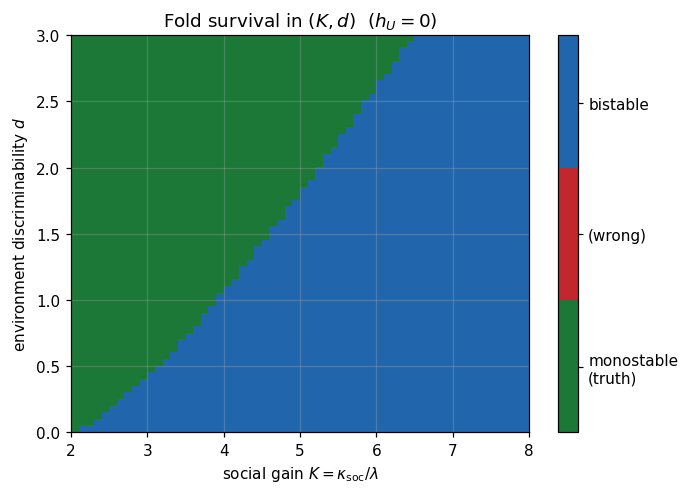

d_crit at K=3: 0.41 | K=5: 1.73 | K=7: 3.00


In [3]:
K_vals = np.linspace(2.0, 8.0, 60)
d_vals = np.linspace(0.0, 3.0, 60)
# h_U = 0 here, so net field = d; as_field=True means field axis IS d
grid = regime_grid(K_vals, d_vals, as_field=True)  # codes: 0 truth, 1 wrong, 2 bistable

cmap = ListedColormap(["#1B7837", "#C2272D", "#2166AC"])
fig, ax = plt.subplots(figsize=(6.4, 4.6))
im = ax.imshow(grid, origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=2,
               extent=[K_vals[0], K_vals[-1], d_vals[0], d_vals[-1]])
ax.set_xlabel(r"social gain $K=\kappa_{\rm soc}/\lambda$")
ax.set_ylabel(r"environment discriminability $d$")
ax.set_title(r"Fold survival in $(K, d)$  ($h_U=0$)")
cbar = fig.colorbar(im, ticks=[0.33, 1.0, 1.66])
cbar.ax.set_yticklabels(["monostable\n(truth)", "(wrong)", "bistable"])
plt.tight_layout(); plt.show()

# d_crit(K): largest d that is still bistable, per K
dcrit = []
for j, Kv in enumerate(K_vals):
    col = grid[:, j]
    bist = np.where(col == BISTABLE)[0]
    dcrit.append(d_vals[bist.max()] if len(bist) else 0.0)
print(f"d_crit at K=3: {dcrit[np.argmin(abs(K_vals-3))]:.2f} | "
      f"K=5: {dcrit[np.argmin(abs(K_vals-5))]:.2f} | "
      f"K=7: {dcrit[np.argmin(abs(K_vals-7))]:.2f}")

## 3. Belief-utility → capture (incl. capture of the *wrong* paradigm)

Now fix a weakly-discriminating environment ($d=0.3$, toward true B) and sweep the belief-utility
field $h_U$. Negative $h_U$ (the population *wants* the false paradigm A true) drives the system
through bistability into **monostable capture by A — against the evidence**. Then a finite-$N$ run
confirms the dynamic outcome.

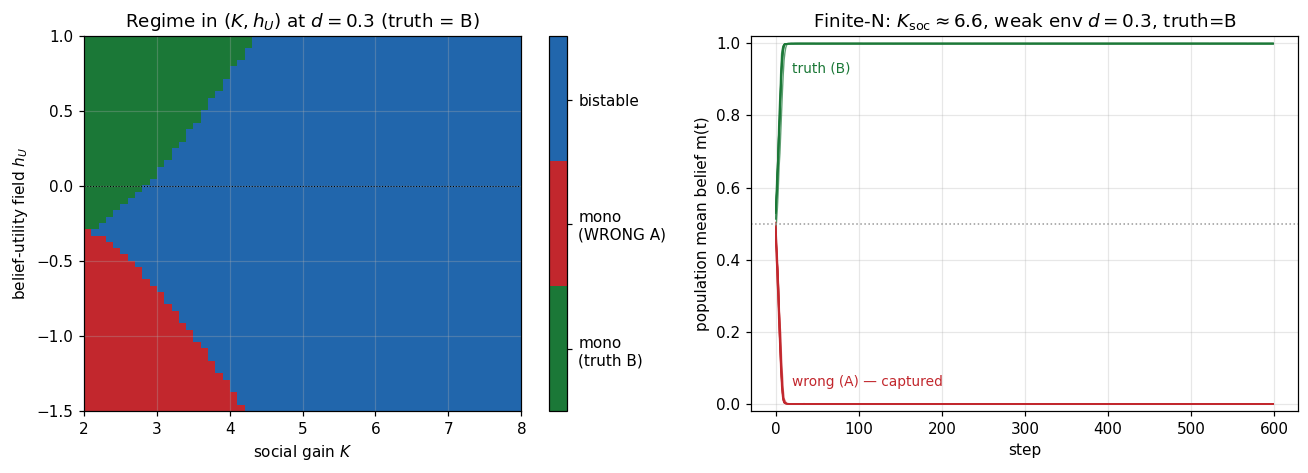

h_U=+0.0: captured-by-wrong-A 0/30, truth-B 30/30


h_U=-0.6: captured-by-wrong-A 30/30, truth-B 0/30


In [4]:
d_fixed = 0.3
K_vals = np.linspace(2.0, 8.0, 60)
hU_vals = np.linspace(-1.5, 1.0, 60)
grid_cap = regime_grid(K_vals, hU_vals, d=d_fixed, as_field=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
im = axes[0].imshow(grid_cap, origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=2,
                    extent=[K_vals[0], K_vals[-1], hU_vals[0], hU_vals[-1]])
axes[0].axhline(0, color="k", lw=0.7, ls=":")
axes[0].set_xlabel(r"social gain $K$"); axes[0].set_ylabel(r"belief-utility field $h_U$")
axes[0].set_title(fr"Regime in $(K, h_U)$ at $d={d_fixed}$ (truth = B)")
cbar = fig.colorbar(im, ax=axes[0], ticks=[0.33, 1.0, 1.66])
cbar.ax.set_yticklabels(["mono\n(truth B)", "mono\n(WRONG A)", "bistable"])

# finite-N: truth=B, strong social, belief-utility toward wrong A => capture
rng = np.random.default_rng(11)
for h_U, lab, col in [(0.0, r"$h_U=0$ (no motivation)", "#1B7837"),
                      (-0.6, r"$h_U=-0.6$ (wants A)", "#C2272D")]:
    cfg = EnvConfig(n_agents=600, q=0.88, leak=0.30, reports_per_step=1,
                    n_steps=600, d_env=d_fixed, h_util=h_U)
    for _ in range(10):
        ell0 = 0.1 * rng.standard_normal(cfg.n_agents)
        tr = simulate_env(cfg, ell0, rng)
        axes[1].plot(tr["m"], lw=0.9, alpha=0.7, color=col)
axes[1].axhline(0.5, color="0.6", ls=":", lw=1)
axes[1].text(20, 0.92, "truth (B)", color="#1B7837", fontsize=9)
axes[1].text(20, 0.05, "wrong (A) — captured", color="#C2272D", fontsize=9)
axes[1].set_xlabel("step"); axes[1].set_ylabel("population mean belief m(t)")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title(r"Finite-N: $K_{\rm soc}\approx6.6$, weak env $d=0.3$, truth=B")
plt.tight_layout(); plt.show()

# quantify
for h_U in [0.0, -0.6]:
    cfg = EnvConfig(n_agents=600, q=0.88, leak=0.30, n_steps=800, d_env=d_fixed, h_util=h_U)
    fm = capture_basin_test(cfg, n_seeds=30, rng=np.random.default_rng(5))["final_m"]
    print(f"h_U={h_U:+}: captured-by-wrong-A {int((fm<0.5).sum())}/30, truth-B {int((fm>0.5).sum())}/30")

## Verdict — PASS, with a stated design constraint

1. **The fold survives the environment** for plausible theory discriminability. At $K=4$ the two-basin
   structure persists up to $d\approx1.5$ before the saddle-node flattens it to monostable-truth; the
   $(K,d)$ map shows stronger social coupling tolerates a more disambiguating environment. **Design
   constraint (honest):** paradigm bistability requires the data to be *sufficiently underdetermined /
   theory-laden* — if experiments sharply separate the paradigms, the truth wins and there is no fold.
   This is a feature, not a bug: it is the Duhem–Quine condition, and it is exactly what the
   per-paradigm likelihood $A_\theta$ (option B) is meant to express.
2. **Belief-utility produces genuine capture.** With weak evidence ($d=0.3$ toward true B) and the
   population valuing the false paradigm A ($h_U<0$), strong social coupling drives the whole
   population into A **against the evidence** (finite-$N$: all seeds → $m\approx0$). This is the
   asymmetric *capture* the symmetric NB15 pitchfork could not produce — now driven by belief-utility
   (motivated reasoning), not resource.

**Green light for the Phase-1 scaffold**, carrying two pins into `gen_model.py`: (i) keep theory
discriminability `d` a swept axis (it sets whether the fold exists); (ii) belief-utility enters the
EFE/policy score (`Σ_θ U(θ)q(θ|π)`), never the belief update.

> **Scope.** Homogeneous mean-field + finite-$N$ with the belief-utility/environment effects modelled
> as net log-odds fields. It is a faithful reduction of the categorical update, not the pymdp
> generative model; motivated sampling is here a field/gain, not yet derived from EFE. The pymdp
> scaffold (Phase 1) is where `U` enters the actual policy evaluation and `d` becomes the real
> per-row KL of $A_\theta$.